# Gaussian Splats — Train 3DGS from a Feedforward Reconstruction

Trains a 3D Gaussian splat on upstream **gsplat** from the reconstruction cached by
`02_pointcloud/feedforward_methods.ipynb` — the same path `Reconstructor.splats()` takes.

Two things to know before running:

- Training uses the **native** keyframes from `frames.zarr` (1080×1920), with the zarr's model-res
  intrinsics rescaled to frame size. Depth targets stay at model resolution; the trainer
  nearest-resizes them.
- `MAX_STEPS = 3000` keeps this notebook to a few minutes on one GPU. The pipeline default is
  30 000 steps; the measured 30k-step numbers (3DGS vs 2DGS, PSNR, Gaussian count, wall-clock) live in
  `docs/superpowers/specs/2026-08-23-splats-measured-report.md`.

**Pipeline:** `pointcloud.zarr` + `frames.zarr` → `inputs_from_pointcloud_zarr()` → `SplatsConfig` → `train()` → `splats/`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import zarr
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use("Agg") if os.environ.get("PYVISTA_OFF_SCREEN") else None
%matplotlib inline

%run ../notebook_utils.py
%run ../tutorial_config.py
set_notebook_backend()

# evals/ is a repo-root package (not installed) — make it importable the way eval_splats.py is run
sys.path.insert(0, str(REPO_ROOT))

from collab_splats.splats import GSPLAT_COMMIT, SplatsConfig, train
from evals.scripts.eval_splats import inputs_from_pointcloud_zarr

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA A40" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

## §0 — Configuration

`RECON` and `FRAMES_ZARR` come from `tutorial_config` (written by notebooks 02 and 01). Splat outputs go to
`OUTPUT_DIR / "splats"` — the same place `06_mesh/splats_mesh.ipynb` reads them from.

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
MAX_STEPS = 3000  # pipeline default is 30000; see the measured report for those numbers
CONF_PERCENTILE = 20.0  # base.yaml mesh.conf_percentile — masks the depth targets
SPLATS_DIR = OUTPUT_DIR / "splats"

assert RECON.exists(), f"missing {RECON} — run 02_pointcloud/feedforward_methods.ipynb first"
assert FRAMES_ZARR.exists(), f"missing {FRAMES_ZARR} — run 01_preprocessing/keyframe_extraction.ipynb first"
print(f"RECON:      {RECON}")
print(f"SPLATS_DIR: {SPLATS_DIR}")
print(f"gsplat:     {GSPLAT_COMMIT}")

RECON:      /workspace/collab-splats-splats/data/outputs/feedforward.zarr
SPLATS_DIR: /workspace/collab-splats-splats/data/outputs/splats
gsplat:     d2f5c0f


## §1 — Trainer inputs

`inputs_from_pointcloud_zarr` bundles everything `train()` needs from one `pointcloud.zarr`: native frames
(it finds `frames.zarr` beside the store automatically), world-to-camera poses, per-frame intrinsics at
frame resolution, the seed pointcloud with colours, and depth targets masked by confidence percentile
(`0` = no target at that pixel).

In [4]:
# Native-resolution frames + rescaled K; depth targets masked by the confidence percentile
inputs = inputs_from_pointcloud_zarr(RECON, conf_percentile=CONF_PERCENTILE)

n_views, height, width, _ = inputs.images.shape
n_points = inputs.points.shape[0]
depth_shape = None if inputs.depth_targets is None else inputs.depth_targets.shape
print(f"images:        {inputs.images.shape}  {inputs.images.dtype}")
print(f"world_to_cam:  {inputs.world_to_cam.shape}")
print(f"intrinsics:    {inputs.intrinsics.shape}")
print(f"points/colors: {inputs.points.shape} / {inputs.colors.shape}")
print(f"depth_targets: {depth_shape}  (model res, 0 = no target)")
print(f"resolution:    {inputs.resolution}  ({n_views} views, {n_points:,} seed points)")

images:        (30, 1920, 1080, 3)  uint8
world_to_cam:  (30, 4, 4)
intrinsics:    (30, 3, 3)
points/colors: (500000, 3) / (500000, 3)
depth_targets: (30, 688, 384)  (model res, 0 = no target)
resolution:    (1920, 1080)  (30 views, 500,000 seed points)


## §2 — Configure and train 3DGS

`SplatsConfig` mirrors the `splats:` block of `configs/base.yaml`. The losses below are the 3DGS defaults:
photometric (0.8 L1 + 0.2 SSIM) is always on; `depth` pulls rendered depth towards the feedforward targets;
`opacity_reg` + `scale_reg` are required by the MCMC densification strategy that 3DGS uses (fixed budget
`cap_max`). `normal_consistency` starts at step 7000 — **beyond `MAX_STEPS`, so it never fires in this
short run**; it is kept so the config matches the pipeline's.

`sh_degree_interval` is shortened so all SH bands unlock within the run (the default 1000 assumes 30k steps).

In [5]:
# 3DGS config: base.yaml defaults, shortened run; SH bands unlock evenly over the run
losses = {
    "depth": {"weight": 0.01},
    "normal_consistency": {"weight": 0.05, "start": 7000},  # start > MAX_STEPS: inactive here
    "opacity_reg": {"weight": 0.01},
    "scale_reg": {"weight": 0.01},
}
cfg = SplatsConfig(
    primitive="3dgs",
    max_steps=MAX_STEPS,
    losses=losses,
    sh_degree_interval=MAX_STEPS // 4,  # sh_degree=3 -> bands 1..3 unlock at 750/1500/2250
    log_every=500,
)

# Train in the COLMAP world frame; writes splats.ply / ckpt.pt / splats.zarr / splats_quality_report.json
SPLATS_DIR.mkdir(parents=True, exist_ok=True)
train(
    cfg,
    inputs.images,
    inputs.world_to_cam,
    inputs.intrinsics,
    inputs.points,
    inputs.colors,
    SPLATS_DIR,
    depth_targets=inputs.depth_targets,
)
print(f"Trained → {SPLATS_DIR}")

splats[3dgs]:   0%|          | 0/3000 [00:00<?, ?frame/s]

splats render:   0%|          | 0/30 [00:00<?, ?frame/s]

Trained → /workspace/collab-splats-splats/data/outputs/splats


## §3 — Outputs

`train()` writes four files: `splats.ply` (the Gaussians, viewer-compatible), `ckpt.pt` (gsplat checkpoint
with the config), `splats.zarr` (rendered rgb / depth / normal / alpha for every training view plus the
poses actually rendered), and `splats_quality_report.json` (summary + per-frame PSNR/SSIM, same shape as
the other stage reports).

ok   /workspace/collab-splats-splats/data/outputs/splats/splats.ply
ok   /workspace/collab-splats-splats/data/outputs/splats/ckpt.pt
ok   /workspace/collab-splats-splats/data/outputs/splats/splats.zarr
ok   /workspace/collab-splats-splats/data/outputs/splats/splats_quality_report.json
{
  "psnr": 17.482432800810617,
  "ssim": 0.5730319917201996,
  "n_gaussians": 1000000,
  "seconds": 102.8,
  "final_losses": {
    "l1": 0.07410643249750137,
    "ssim": 0.45183300971984863,
    "depth": 0.1584274023771286,
    "opacity_reg": 0.23622065782546997,
    "scale_reg": 0.0015497161075472832
  }
}


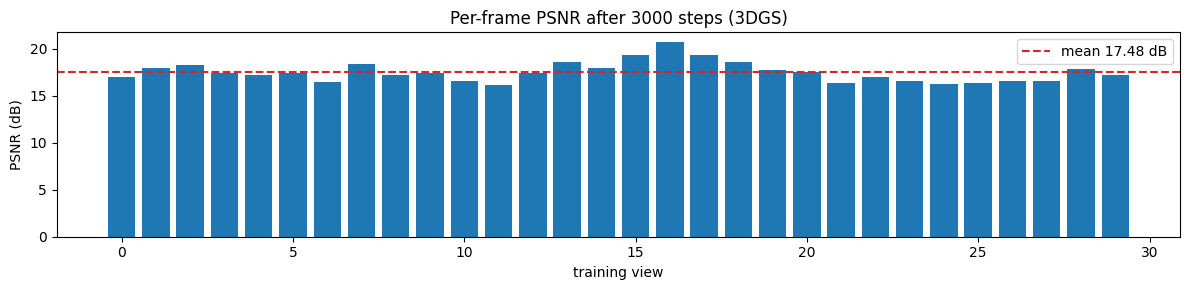

In [6]:
# The four stage outputs
for name in ("splats.ply", "ckpt.pt", "splats.zarr", "splats_quality_report.json"):
    path = SPLATS_DIR / name
    print(f"{'ok ' if path.exists() else 'MISSING'}  {path}")

# Summary block of the quality report
report = json.loads((SPLATS_DIR / "splats_quality_report.json").read_text())
summary = report["summary"]
print(json.dumps({key: value for key, value in summary.items() if key != "config"}, indent=2))

# Per-frame PSNR — a dip flags a view the splat fits badly (motion blur, exposure, pose error)
per_frame = report["per_frame"]
frame_ids = [frame["image_id"] for frame in per_frame]
psnr = [frame["psnr"] for frame in per_frame]
mean_psnr = summary["psnr"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(psnr)), psnr, color="tab:blue")
ax.axhline(mean_psnr, color="tab:red", linestyle="--", label=f"mean {mean_psnr:.2f} dB")
ax.set_xlabel("training view")
ax.set_ylabel("PSNR (dB)")
ax.set_title(f"Per-frame PSNR after {MAX_STEPS} steps (3DGS)")
ax.legend()
plt.tight_layout()
plt.show()

## §4 — Render gallery

`splats.zarr` holds one render per training view. RGB is uint8; depth and alpha are float32; normals are
unit vectors in the **camera frame**, shown here as `(n + 1) / 2` so x/y/z map to r/g/b.

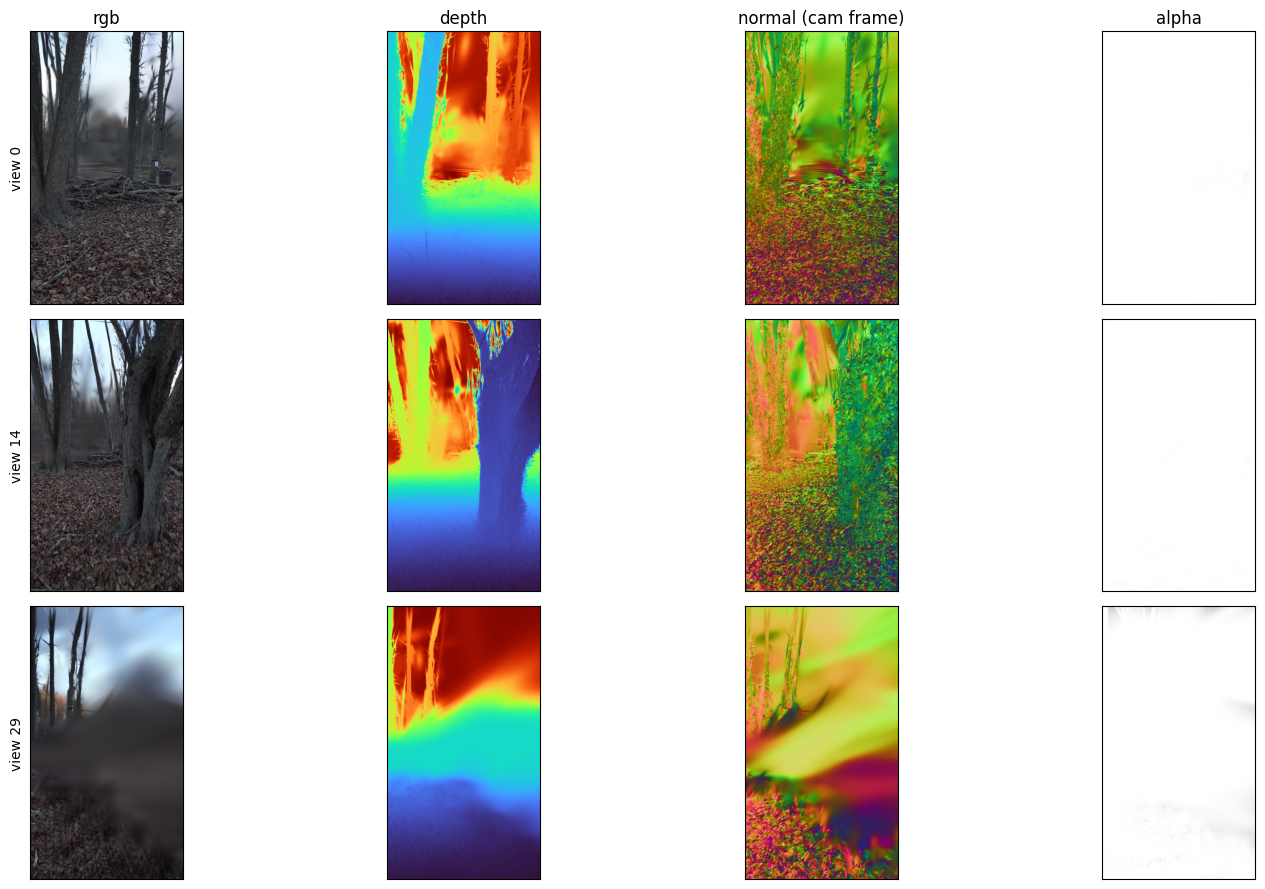

In [7]:
# Three views spread across the sequence: rgb / depth / normal / alpha
renders = zarr.open_group(str(SPLATS_DIR / "splats.zarr"), mode="r")
n_rendered = renders["rgb"].shape[0]
view_ids = np.linspace(0, n_rendered - 1, 3).astype(int)

fig, axes = plt.subplots(len(view_ids), 4, figsize=(16, 3 * len(view_ids)))
for row, view in enumerate(view_ids):
    rgb = renders["rgb"][view]
    depth = renders["depth"][view]
    normal = renders["normal"][view]
    alpha = renders["alpha"][view]

    # Depth shown only where something was rendered; normals remapped from [-1, 1] to [0, 1]
    depth_shown = np.where(alpha > 0, depth, np.nan)
    normal_shown = np.clip((normal + 1.0) / 2.0, 0.0, 1.0)

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(depth_shown, cmap="turbo")
    axes[row, 2].imshow(normal_shown)
    axes[row, 3].imshow(alpha, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(f"view {view}")

for ax, title in zip(axes[0], ("rgb", "depth", "normal (cam frame)", "alpha")):
    ax.set_title(title)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## §5 — 2DGS

The same `train()` call trains **2D Gaussian splats** (surfels) by switching the primitive. Two things change
with it, and both are enforced by `SplatsConfig.from_dict` / the trainer rather than left to the user:

- Densification is primitive-bound: 3DGS uses `MCMCStrategy` (fixed `cap_max` budget, needs
  `opacity_reg` + `scale_reg`), 2DGS uses gsplat's `DefaultStrategy` (`grow_grad2d` gradient threshold,
  opacity reset every 3000 steps).
- The regularisers swap: `opacity_reg` / `scale_reg` are replaced by the 2DGS `distortion` loss, which
  starts at step 3000 (`distortion` with `primitive="3dgs"` is rejected).

The config diff against §2:

```python
losses = {
    "depth": {"weight": 0.01},
    "normal_consistency": {"weight": 0.05, "start": 7000},
    "distortion": {"weight": 0.01, "start": 3000},  # replaces opacity_reg + scale_reg
}
cfg = SplatsConfig(primitive="2dgs", max_steps=MAX_STEPS, losses=losses, sh_degree_interval=MAX_STEPS // 4)
train(cfg, inputs.images, inputs.world_to_cam, inputs.intrinsics, inputs.points, inputs.colors,
      OUTPUT_DIR / "splats_2dgs", depth_targets=inputs.depth_targets)
```

It is not run here: at `MAX_STEPS = 3000` the distortion loss would never activate and `DefaultStrategy`
has barely begun growing, so a 3000-step 2DGS tells you nothing the 3DGS run above does not. The
3DGS-vs-2DGS comparison at 30k steps (PSNR, Gaussian count, wall-clock, depth quality) is in the measured
report referenced in the intro. Pipeline equivalent: `splats.primitive: 2dgs` in the config.